In [17]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [31]:
import os
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
import importlib
import conv_helpers
importlib.reload(conv_helpers)
from conv_helpers import encoding, ideal_syndrome_meas, ideal_recovery, logical_msd_all_errors, logical_msd_no_errors, logical_msd_meas_errors, logical_msd_2q_errors, logical_msd_1q_errors

# Defining Global Variable

In [19]:
x_star = 1/3 * (-2 + np.cbrt(19-3*np.sqrt(33)) + np.cbrt(19+3*np.sqrt(33)))
theta = np.arcsin(x_star)

# Graphing Settings

In [20]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Qubit Labeling of Steane Code

Qubits are ordered from top to down, left to right, increasingly

The logical operators act on the left side of the triangle

# Infidelity to Error Rates

In [21]:
def inf_to_error(infidelity_list, num_qubits, infidelity_uncertainty_list=None):
    error_rates_list = []

    alpha_star = np.sqrt((1 - x_star) / 2)
    beta_star = -np.sqrt((1 + x_star) / 2)

    noisy_ket = alpha_star * np.array([[1], [0]]) + beta_star * np.array([[0], [1]])
    ry_theta = np.array([[np.cos(theta/2), -np.sin(theta/2)], [np.sin(theta/2), np.cos(theta/2)]])
    target_ket = ry_theta @ np.array([[1], [0]])

    scale = 1 / (1 - np.abs(np.vdot(target_ket, noisy_ket))**2)

    for infidelity in infidelity_list:
        error_rates_list.append(scale * infidelity)

    if infidelity_uncertainty_list is None:
        return error_rates_list

    error_uncertainty_list = []

    for uncertainty in infidelity_uncertainty_list:
        error_uncertainty_list.append(scale * uncertainty)

    return error_rates_list, error_uncertainty_list

In [22]:
one_qubit_gate_infidelity = [2.8e-5 * i for i in range(1,6)]
two_qubit_gate_infidelity = [8.3e-4 * i for i in range(1,6)]
idle_gate_infidelity = [1.2e-4 * i for i in range(1,6)]
spam0 = [6.7e-4 * i for i in range(1,6)] # P(1|0), measured 1 given that 0 was prepared
spam1 = [1.2e-3 * i for i in range(1,6)] # P(0|1)

In [23]:
one_qubit_gate_error_prob = inf_to_error(one_qubit_gate_infidelity, num_qubits=1)
two_qubit_gate_error_prob = inf_to_error(two_qubit_gate_infidelity, num_qubits=2)
idle_gate_error_prob = inf_to_error(idle_gate_infidelity, num_qubits=1)

# Simulations

Case: Logical MSD with all errors

In [12]:
# Initializing lists for later calculations of average fidelity and uncertainty for each error probability
# Also keeping track of total shots 
sum_fid_all_errors_list = np.zeros(5, dtype=float)
accepted_all_errors_list = np.zeros(5, dtype=float)
total_shots_all_errors = 0

In [14]:
# Can be ran multiple times
# Dividing into smaller batches to ensure memory doesn't run out
num_shots = 50
batch_shots = 25

for p in range(len(spam0)):
    for _ in range(num_shots//batch_shots):
        sumfid, accepted = logical_msd_all_errors(batch_shots, one_qubit_gate_error_prob[p], two_qubit_gate_error_prob[p], spam0[p], spam1[p])
    
        sum_fid_all_errors_list[p] += sumfid
        accepted_all_errors_list[p] += accepted
    
total_shots_all_errors = total_shots_all_errors + num_shots

In [15]:
# Calculating the average fidelity and uncertainty per physical error rate
avg_fid_all_errors_list = []
avg_fid_all_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_all_errors_list[i]/accepted_all_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_all_errors_list[i])
    avg_fid_all_errors_list.append(avg_fid)
    avg_fid_all_errors_unc_list.append(avg_fid_unc)

# Loading Data from Cluster

In [24]:
data = np.load("cluster_logical_msd_all_errors.npz")
sum_fid_all_errors_list = data["sum_fid_list"]
accepted_all_errors_list = data["accepted_list"]
total_shots_all_errors = data["total_shots"].item()

data = np.load("cluster_logical_msd_no_errors.npz")
sum_fid_no_errors_list = data["sum_fid_list"]
accepted_no_errors_list = data["accepted_list"]
total_shots_no_errors = data["total_shots"].item()

data = np.load("cluster_logical_msd_meas_errors.npz")
sum_fid_meas_errors_list = data["sum_fid_list"]
accepted_meas_errors_list = data["accepted_list"]
total_shots_meas_errors = data["total_shots"].item()

data = np.load("cluster_logical_msd_2q_errors.npz")
sum_fid_2q_errors_list = data["sum_fid_list"]
accepted_2q_errors_list = data["accepted_list"]
total_shots_2q_errors = data["total_shots"].item()

data = np.load("cluster_logical_msd_1q_errors.npz")
sum_fid_1q_errors_list = data["sum_fid_list"]
accepted_1q_errors_list = data["accepted_list"]
total_shots_1q_errors = data["total_shots"].item()

In [25]:
print(total_shots_all_errors)
print(total_shots_no_errors)
print(total_shots_meas_errors)
print(total_shots_2q_errors)
print(total_shots_1q_errors)

600000
600000
600000
600000
600000


In [26]:
# Calculating the average fidelity and uncertainty per physical error rate
avg_fid_all_errors_list = []
avg_fid_all_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_all_errors_list[i]/accepted_all_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_all_errors_list[i])
    avg_fid_all_errors_list.append(avg_fid)
    avg_fid_all_errors_unc_list.append(avg_fid_unc)
    
avg_fid_no_errors_list = []
avg_fid_no_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_no_errors_list[i]/accepted_no_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_no_errors_list[i])
    avg_fid_no_errors_list.append(avg_fid)
    avg_fid_no_errors_unc_list.append(avg_fid_unc)
    
avg_fid_meas_errors_list = []
avg_fid_meas_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_meas_errors_list[i]/accepted_meas_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_meas_errors_list[i])
    avg_fid_meas_errors_list.append(avg_fid)
    avg_fid_meas_errors_unc_list.append(avg_fid_unc)
    
avg_fid_2q_errors_list = []
avg_fid_2q_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_2q_errors_list[i]/accepted_2q_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_2q_errors_list[i])
    avg_fid_2q_errors_list.append(avg_fid)
    avg_fid_2q_errors_unc_list.append(avg_fid_unc)
    
avg_fid_1q_errors_list = []
avg_fid_1q_errors_unc_list = []
for i in range(len(spam0)):
    avg_fid = sum_fid_1q_errors_list[i]/accepted_1q_errors_list[i]
    avg_fid_unc = 1.96 * np.sqrt( (avg_fid)*(1 - avg_fid) / accepted_1q_errors_list[i])
    avg_fid_1q_errors_list.append(avg_fid)
    avg_fid_1q_errors_unc_list.append(avg_fid_unc)

In [27]:
list1 = [1 - f for f in avg_fid_all_errors_list]
list2 = [1 - f for f in avg_fid_no_errors_list]
list3 = [1 - f for f in avg_fid_meas_errors_list]
list4 = [1 - f for f in avg_fid_2q_errors_list]
list5 = [1 - f for f in avg_fid_1q_errors_list]

all_output_error_rate, all_output_error_rate_unc = inf_to_error(list1, 1, avg_fid_all_errors_unc_list)
ideal_output_error_rate, ideal_output_error_rate_unc = inf_to_error(list2, 1, avg_fid_no_errors_unc_list)
meas_output_error_rate, meas_output_error_rate_unc = inf_to_error(list3, 1, avg_fid_meas_errors_unc_list)
two_q_output_error_rate, two_q_output_error_rate_unc = inf_to_error(list4, 1, avg_fid_2q_errors_unc_list)
one_q_output_error_rate, one_q_output_error_rate_unc = inf_to_error(list5, 1, avg_fid_1q_errors_unc_list)

# Calculating Infidelity Contributions

In [28]:
sum_c_list = []
for i in range(len(one_qubit_gate_error_prob)):
    sum_c_list.append(meas_output_error_rate[i] + two_q_output_error_rate[i] + one_q_output_error_rate[i])

one_qubit_contributions = 0
two_qubit_contributions = 0
measurement_contributions = 0
for i in range(len(one_qubit_gate_error_prob)):
    one_qubit_contributions += one_q_output_error_rate[i] / sum_c_list[i]
    two_qubit_contributions += two_q_output_error_rate[i] / sum_c_list[i]
    measurement_contributions += meas_output_error_rate[i] / sum_c_list[i]

one_qubit_contributions /= len(one_qubit_gate_error_prob)
two_qubit_contributions /= len(one_qubit_gate_error_prob)
measurement_contributions /= len(one_qubit_gate_error_prob)

# Final Plot

In [29]:
data = np.load("../../physical_level/one_round/convergence_axis_error_rates.npz")
optimal_output_error_rate = data["ideal_output_error_rate"]

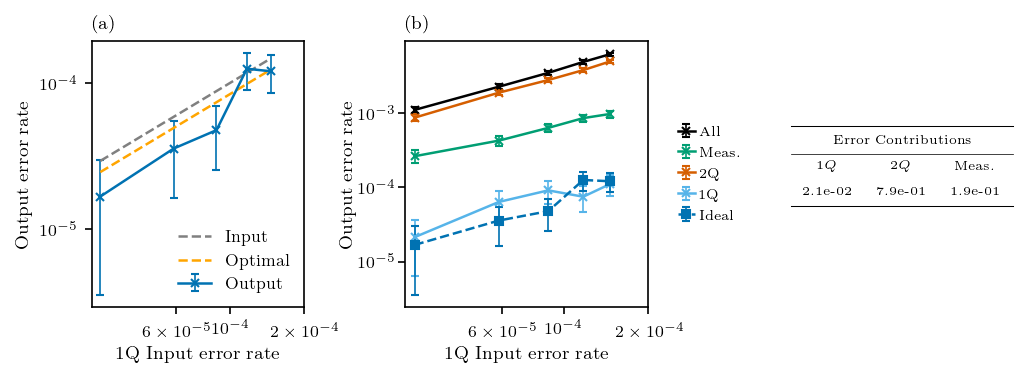

In [32]:
fig = plt.figure(figsize=(6.75, 2.65))

# Layout:
# plot 1 | spacer | plot 2 | legend | spacer | table
gs = GridSpec(
    1, 6,
    figure=fig,
    width_ratios=[1.0, 0.45, 1.15, 0.55, 0.08, 1.05],
    wspace=0.02
)

ax1 = fig.add_subplot(gs[0])
ax_spacer_12 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
ax_leg = fig.add_subplot(gs[3])
ax_spacer_lt = fig.add_subplot(gs[4])
ax_table = fig.add_subplot(gs[5])

ax_spacer_12.axis('off')
ax_spacer_lt.axis('off')
ax_leg.axis('off')
ax_table.axis('off')

# ── Plot 1 ───────────────────────────────────────────────
ax1.errorbar(
    one_qubit_gate_error_prob,
    ideal_output_error_rate,
    yerr=ideal_output_error_rate_unc,
    fmt='x',
    linestyle='-',
    capsize=2,
    elinewidth=0.8,
    color='#0072B2',
    markersize=4,
    label='Output'
)

ax1.plot(
    one_qubit_gate_error_prob,
    one_qubit_gate_error_prob,
    linestyle='--',
    color='gray',
    label='Input'
)

ax1.plot(
    one_qubit_gate_error_prob,
    optimal_output_error_rate,
    linestyle='--',
    color='orange',
    label='Optimal'
)

ax1.set_xscale('log')
ax1.set_yscale('log')

ax1.set_xticks([6e-5, 1e-4, 2e-4])
ax1.set_xticklabels([r'$6\times10^{-5}$', r'$10^{-4}$', r'$2\times10^{-4}$'])
ax1.xaxis.set_minor_locator(mticker.NullLocator())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())
ax1.yaxis.set_minor_locator(mticker.NullLocator())
ax1.yaxis.set_minor_formatter(mticker.NullFormatter())

ax1.legend(frameon=False, loc='lower right')
ax1.set_ylabel("Output error rate")
ax1.set_xlabel("1Q Input error rate")
ax1.set_title('(a)', loc='left', fontsize=9)

# ── Plot 2 ───────────────────────────────────────────────
series = [
    ('#000000', all_output_error_rate,  all_output_error_rate_unc),
    ('#009E73', meas_output_error_rate, meas_output_error_rate_unc),
    ('#D55E00', two_q_output_error_rate,   two_q_output_error_rate_unc),
    ('#56B4E9', one_q_output_error_rate,   one_q_output_error_rate_unc),
    ('#0072B2', ideal_output_error_rate,   ideal_output_error_rate_unc),
]

labels = [
    'All',
    'Meas.',
    '2Q',
    '1Q',
    'Ideal'
]

fmts = ['x', 'x', 'x', 'x', 's']
lss  = ['-', '-', '-', '-', '--']

for (color, y, yerr), label, fmt, ls in zip(series, labels, fmts, lss):
    ax2.errorbar(
        one_qubit_gate_error_prob,
        y,
        yerr=yerr,
        fmt=fmt,
        linestyle=ls,
        color=color,
        capsize=2,
        elinewidth=0.8,
        markersize=4,
        label=label
    )

ax2.set_xscale('log')
ax2.set_yscale('log')

ax2.set_xticks([6e-5, 1e-4, 2e-4])
ax2.set_xticklabels([r'$6\times10^{-5}$', r'$10^{-4}$', r'$2\times10^{-4}$'])
ax2.xaxis.set_minor_locator(mticker.NullLocator())
ax2.xaxis.set_minor_formatter(mticker.NullFormatter())
ax2.yaxis.set_minor_locator(mticker.NullLocator())
ax2.yaxis.set_minor_formatter(mticker.NullFormatter())

ax2.set_ylabel("Output error rate")
ax2.set_xlabel("1Q Input error rate")
ax2.set_title('(b)', loc='left', fontsize=9)

# Make plot 2 y-axis compact
ax2.yaxis.labelpad = 1
ax2.tick_params(axis='y', which='both', pad=1)

# ── Legend to the right of Plot 2 ─────────────────────────
handles, legend_labels = ax2.get_legend_handles_labels()

ax_leg.legend(
    handles,
    legend_labels,
    loc='center',
    frameon=False,
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.65,
    borderaxespad=0.0
)

# ── Table to the right of the legend ──────────────────────
ax_table.axis('off')
ax_table.set_xlim(0, 1)
ax_table.set_ylim(0, 1)

headers = [r'$1Q$', r'$2Q$', r'Meas.']
values = [
    f'{one_qubit_contributions:.1e}',
    f'{two_qubit_contributions:.1e}',
    f'{measurement_contributions:.1e}'
]

# Table position inside ax_table
x0 = 0.00
y0 = 0.38
width = 1.00
height = 0.30

col_w = width / 3

# Row y-positions
y_title = y0 + 0.82 * height
y_header = y0 + 0.50 * height
y_values = y0 + 0.18 * height

# Horizontal rule positions
y_top = y0 + height
y_mid = y0 + 0.65 * height
y_bottom = y0

# Font sizes
fs_title = 6.2
fs_body = 5.8

# Title
ax_table.text(
    x0 + width / 2,
    y_title,
    'Error Contributions',
    ha='center',
    va='center',
    fontsize=fs_title,
    fontweight='semibold',
    transform=ax_table.transAxes
)

# Horizontal rules only
ax_table.plot(
    [x0, x0 + width],
    [y_top, y_top],
    color='black',
    linewidth=0.5,
    transform=ax_table.transAxes,
    clip_on=False
)

ax_table.plot(
    [x0, x0 + width],
    [y_mid, y_mid],
    color='black',
    linewidth=0.35,
    transform=ax_table.transAxes,
    clip_on=False
)

ax_table.plot(
    [x0, x0 + width],
    [y_bottom, y_bottom],
    color='black',
    linewidth=0.5,
    transform=ax_table.transAxes,
    clip_on=False
)

# Headers and values
for j, header in enumerate(headers):
    x = x0 + (j + 0.5) * col_w

    ax_table.text(
        x,
        y_header,
        header,
        ha='center',
        va='center',
        fontsize=fs_body,
        transform=ax_table.transAxes
    )

    ax_table.text(
        x,
        y_values,
        values[j],
        ha='center',
        va='center',
        fontsize=fs_body,
        transform=ax_table.transAxes
    )

# Compact APS-style margins
fig.subplots_adjust(
    left=0.08,
    right=0.99,
    bottom=0.23,
    top=0.90
)

plt.show()